In [14]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import timm, types, sys
from pathlib import Path
from tqdm.auto import tqdm
from torch.utils.data import DataLoader
from peft import LoraConfig
from peft.tuners.lora import LoraModel
from sklearn.metrics import f1_score
import torchvision.transforms as T

sys.path.append(".")
from src.dataset import HistologicalImageDataset

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")

Device: cuda


In [15]:
DATASET_NAME = "BREAKHIS"   # cambia qui per altri dataset

CFG = dict(
    data_dir        = f"/data/{DATASET_NAME}",
    img_size        = 224,
    batch_size      = 64,
    num_workers     = 8,
    seed            = 42,
    classifier_ckpt = Path(f"checkpoints/{DATASET_NAME}/uni_finetuned/best_model.pt"),
    forecaster_ckpt = Path(f"checkpoints/{DATASET_NAME}/forecaster/forecaster_src02_tgt23.pt"),
    finetuned_pruned_ckpt = Path(f"checkpoints/{DATASET_NAME}/pruned_finetuned/best_prune_layer2_keep10.pt"),
    results_dir     = Path(f"results/{DATASET_NAME}"),
    prune_layer     = 2,
    far_threshold   = 1e-4,
    keep_ratios     = [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8],
)
torch.manual_seed(CFG["seed"])
np.random.seed(CFG["seed"])
CFG["results_dir"].mkdir(parents=True, exist_ok=True)


In [16]:
eval_tf = T.Compose([
    T.Resize((CFG["img_size"], CFG["img_size"])),
    T.Normalize((0.485,0.456,0.406),(0.229,0.224,0.225)),
])
test_ds     = HistologicalImageDataset(f"{CFG['data_dir']}/test", transform=eval_tf)
test_loader = DataLoader(test_ds, batch_size=CFG["batch_size"],
                         shuffle=False, num_workers=CFG["num_workers"],
                         pin_memory=True, persistent_workers=True)
CLASS_NAMES = test_ds.class_names
N_CLASSES   = len(CLASS_NAMES)
print(f"Test samples: {len(test_ds)} | Classi: {CLASS_NAMES}")


Loading from /data/BREAKHIS/test...
Loaded 6833 samples, 8 classes
Class distribution:
  adenosis: 540 (7.9%)
  fibroadenoma: 693 (10.1%)
  phyllodes_tumor: 423 (6.2%)
  tubular_adenoma: 602 (8.8%)
  ductal_carcinoma: 2769 (40.5%)
  lobular_carcinoma: 602 (8.8%)
  mucinous_carcinoma: 757 (11.1%)
  papillary_carcinoma: 447 (6.5%)


Test samples: 6833 | Classi: ['adenosis', 'fibroadenoma', 'phyllodes_tumor', 'tubular_adenoma', 'ductal_carcinoma', 'lobular_carcinoma', 'mucinous_carcinoma', 'papillary_carcinoma']


In [17]:
def compute_tar_at_far(scores, is_correct, far_threshold=1e-4):
    scores    = np.array(scores)
    correct   = np.array(is_correct).astype(bool)
    incorrect = ~correct
    if incorrect.sum() == 0:
        return 1.0
    n_far     = max(1, int(np.ceil(incorrect.sum() * far_threshold)))
    threshold = np.sort(scores[incorrect])[::-1][min(n_far-1, incorrect.sum()-1)]
    return float((scores[correct] >= threshold).mean())


def compute_metrics(all_preds, all_labels, all_scores, far_threshold=1e-4):
    all_preds  = np.array(all_preds)
    all_labels = np.array(all_labels)
    all_scores = np.array(all_scores)
    f1         = f1_score(all_labels, all_preds, average='macro', zero_division=0)
    is_correct = (all_preds == all_labels)
    tar        = compute_tar_at_far(all_scores, is_correct, far_threshold)
    return {"f1_macro": f1, "tar_at_far": tar}


In [18]:
class UNILoRAClassifier(nn.Module):
    def __init__(self, n_classes, dropout=0.1):
        super().__init__()
        backbone = timm.create_model("hf-hub:MahmoodLab/uni", pretrained=True,
                                      init_values=1e-5, dynamic_img_size=True)
        lora_config = LoraConfig(r=8, lora_alpha=32,
            target_modules=["qkv","proj","fc1","fc2"],
            lora_dropout=0.1, bias="none")
        self.backbone = LoraModel(backbone, lora_config, adapter_name="default")
        self.head = nn.Sequential(
            nn.LayerNorm(1024), nn.Dropout(dropout), nn.Linear(1024, n_classes))
    def forward(self, x):
        return self.head(self.backbone(x))


class AttentionForecaster(nn.Module):
    def __init__(self, embed_dim=1024, hidden=256, n_heads=4, n_layers=2, dropout=0.1):
        super().__init__()
        self.input_proj  = nn.Linear(embed_dim, hidden)
        self.cls_query   = nn.Parameter(torch.randn(1,1,hidden)*0.02)
        self.self_attn   = nn.ModuleList([
            nn.TransformerEncoderLayer(d_model=hidden, nhead=n_heads,
                dim_feedforward=hidden*2, dropout=dropout,
                batch_first=True, norm_first=True) for _ in range(n_layers)])
        self.cross_attn  = nn.ModuleList([
            nn.MultiheadAttention(hidden, n_heads, dropout=dropout, batch_first=True)
            for _ in range(n_layers)])
        self.cross_norms = nn.ModuleList([nn.LayerNorm(hidden) for _ in range(n_layers)])
        self.norm        = nn.LayerNorm(hidden)
        self.score_head  = nn.Sequential(
            nn.Linear(hidden*2,128), nn.GELU(), nn.Dropout(dropout), nn.Linear(128,1))
    def forward(self, x):
        B, N, D = x.shape
        x = self.input_proj(x)
        for sa in self.self_attn: x = sa(x)
        cls = self.cls_query.expand(B,-1,-1)
        for ca, norm in zip(self.cross_attn, self.cross_norms):
            cls_out, _ = ca(cls, x, x); cls = norm(cls + cls_out)
        x_norm  = self.norm(x)
        cls_exp = cls.expand(-1,N,-1)
        return self.score_head(torch.cat([x_norm,cls_exp],dim=-1)).squeeze(-1).softmax(-1)


# Carica classificatore fine-tuned
classifier = UNILoRAClassifier(N_CLASSES).to(device)
classifier.load_state_dict(
    torch.load(CFG["classifier_ckpt"], map_location=device), strict=False)
classifier.eval()
for p in classifier.parameters(): p.requires_grad_(False)

# Carica forecaster
forecaster = AttentionForecaster().to(device)
forecaster.load_state_dict(torch.load(CFG["forecaster_ckpt"], map_location=device))
forecaster.eval()
for p in forecaster.parameters(): p.requires_grad_(False)

# Carica classificatore fine-tuned CON pruning
classifier_ft_pruned = UNILoRAClassifier(N_CLASSES).to(device)
classifier_ft_pruned.load_state_dict(
    torch.load(CFG["finetuned_pruned_ckpt"], map_location=device), strict=False)
classifier_ft_pruned.eval()
for p in classifier_ft_pruned.parameters(): p.requires_grad_(False)

print("Modelli caricati")

Modelli caricati


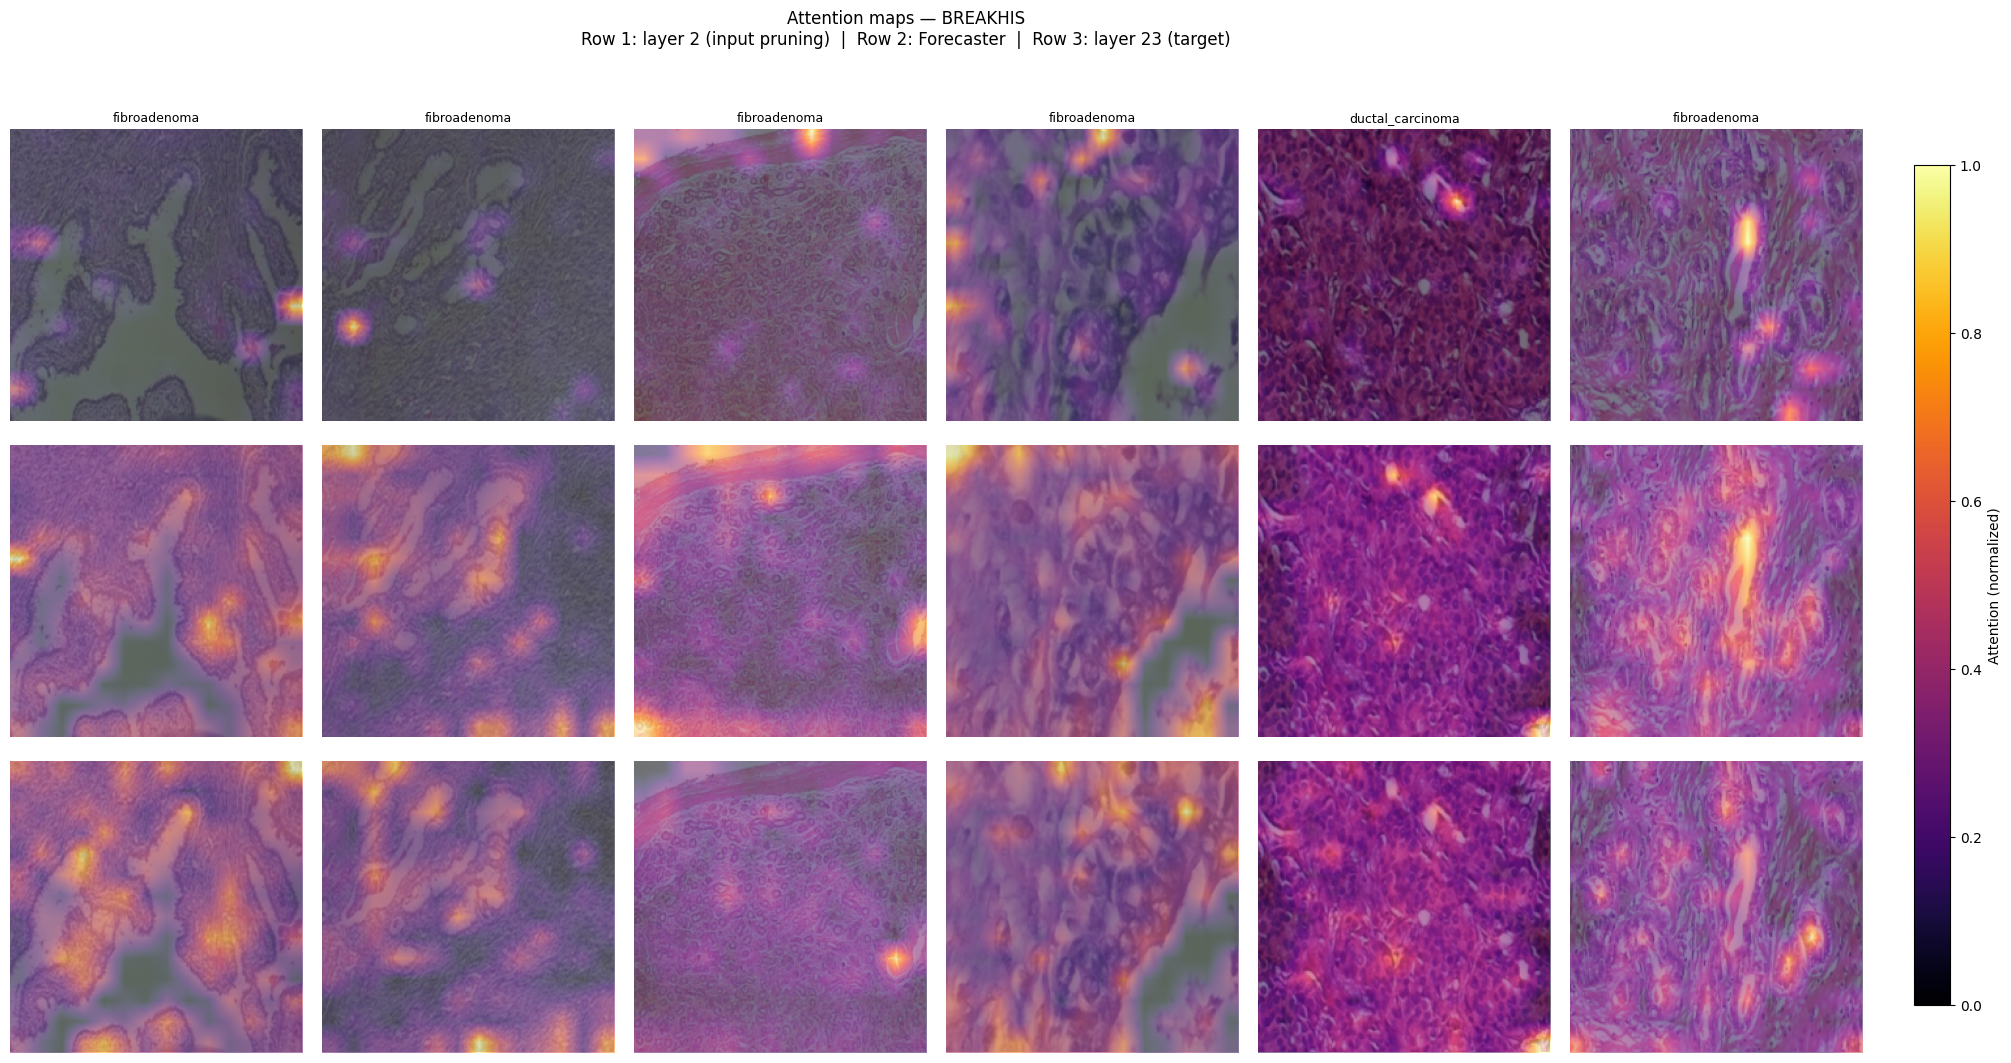

In [19]:
import matplotlib.gridspec as gridspec

N_IMAGES    = 6      # immagini da visualizzare
PRUNE_LAYER = CFG["prune_layer"]
TARGET_LAYER = 23

# %%
def collect_attention_maps(model, forecaster, imgs_dev, prune_layer, target_layer):
    """
    Raccoglie per ogni immagine:
    - CLS attention @ prune_layer     (classificatore)
    - Importanza predetta forecaster  (dagli emb @ prune_layer)
    - CLS attention @ target_layer    (classificatore)
    """
    cache = {}
    orig  = {}

    def make_hook(idx):
        def fwd(self, x):
            B, N, C = x.shape
            qkv  = self.qkv(x).reshape(B,N,3,self.num_heads,
                             self.head_dim).permute(2,0,3,1,4)
            q, k, v = qkv.unbind(0)
            q, k   = self.q_norm(q), self.k_norm(k)
            attn   = (q @ k.transpose(-2,-1) * self.scale).softmax(-1)
            if idx == prune_layer:
                cache["emb_x"]    = x[:, 1:].detach()           # [B, 196, D]
                cache["attn_x"]   = attn[:,:,0,1:].mean(1).detach()  # [B, 196]
            if idx == target_layer:
                cache["attn_y"]   = attn[:,:,0,1:].mean(1).detach()  # [B, 196]
            x = (self.attn_drop(attn) @ v).transpose(1,2).reshape(B,N,C)
            return self.proj_drop(self.proj(x))
        return fwd

    for i, block in enumerate(model.backbone.model.blocks):
        orig[i] = block.attn.forward
        block.attn.forward = types.MethodType(make_hook(i), block.attn)

    with torch.no_grad():
        model(imgs_dev)
        pred_importance = forecaster(cache["emb_x"])  # [B, 196]

    for i, block in enumerate(model.backbone.model.blocks):
        block.attn.forward = orig[i]

    return (cache["attn_x"].cpu(),       # [B, 196]
            pred_importance.cpu(),        # [B, 196]
            cache["attn_y"].cpu())        # [B, 196]


# %%
# Prendi N_IMAGES dal test set
sample_imgs, sample_labels = [], []
for imgs, labels in test_loader:
    sample_imgs.append(imgs)
    sample_labels.append(labels)
    if sum(len(x) for x in sample_imgs) >= N_IMAGES:
        break
sample_imgs   = torch.cat(sample_imgs)[:N_IMAGES]
sample_labels = torch.cat(sample_labels)[:N_IMAGES]

imgs_dev = sample_imgs.to(device)

attn_x, attn_pred, attn_y = collect_attention_maps(
    classifier, forecaster, imgs_dev, PRUNE_LAYER, TARGET_LAYER)


# %%
def to_map(vec):
    """[196] → [14,14] normalizzato in [0,1]."""
    m = vec.reshape(14,14).numpy()
    m = (m - m.min()) / (m.max() - m.min() + 1e-8)
    return m

def unnorm(img_tensor):
    """Denormalizza ImageNet → [0,1]."""
    mean = torch.tensor([0.485,0.456,0.406]).view(3,1,1)
    std  = torch.tensor([0.229,0.224,0.225]).view(3,1,1)
    img  = img_tensor * std + mean
    return img.permute(1,2,0).clamp(0,1).numpy()


# %%
CMAP     = "inferno"
ALPHA    = 0.55
TITLES   = [
    f"CLS attn @ layer {PRUNE_LAYER}\n(no fine-tuning)",
    f"Forecaster prediction\n(@ layer {PRUNE_LAYER} → {TARGET_LAYER})",
    f"CLS attn @ layer {TARGET_LAYER}\n(ground truth)",
]

fig = plt.figure(figsize=(4 * (N_IMAGES), 4 * 3))
gs  = gridspec.GridSpec(3, N_IMAGES, hspace=0.08, wspace=0.04)

for col in range(N_IMAGES):
    img_np = unnorm(sample_imgs[col])
    maps   = [to_map(attn_x[col]),
              to_map(attn_pred[col]),
              to_map(attn_y[col])]

    for row, (m, title) in enumerate(zip(maps, TITLES)):
        ax = fig.add_subplot(gs[row, col])
        ax.imshow(img_np)
        im = ax.imshow(m, cmap=CMAP, alpha=ALPHA,
                       extent=[0,224,224,0], interpolation="bilinear",
                       vmin=0, vmax=1)
        ax.axis("off")
        if col == 0:
            ax.set_ylabel(title, fontsize=10, labelpad=6)
        if row == 0:
            ax.set_title(CLASS_NAMES[sample_labels[col]], fontsize=9)

# Colorbar comune
cbar_ax = fig.add_axes([0.92, 0.15, 0.015, 0.7])
sm = plt.cm.ScalarMappable(cmap=CMAP, norm=plt.Normalize(0,1))
fig.colorbar(sm, cax=cbar_ax, label="Attention (normalized)")

fig.suptitle(
    f"Attention maps — {DATASET_NAME}\n"
    f"Row 1: layer {PRUNE_LAYER} (input pruning)  |  "
    f"Row 2: Forecaster  |  "
    f"Row 3: layer {TARGET_LAYER} (target)",
    fontsize=12, y=0.98)

out_pdf = CFG["results_dir"] / "attention_maps_comparison.pdf"
fig.savefig(out_pdf, dpi=300, bbox_inches="tight")
fig.savefig(str(out_pdf).replace(".pdf",".png"), dpi=300, bbox_inches="tight")
plt.show()

In [20]:
def forward_with_pruning(model, imgs, device, prune_layer, keep_ratio, score_fn):
    """
    score_fn: callable(patch_emb [B,196,D], attn [B,H,N,N]) → scores [B,196]
    Esegue pruning fisico dopo prune_layer.
    """
    cache = {}
    orig_blocks = {}

    def make_block_hook(idx):
        orig_fwd = model.backbone.model.blocks[idx].forward
        def block_fwd(x):
            # Hook separato sull'attention per catturare attn weights
            attn_cache = {}
            orig_attn  = model.backbone.model.blocks[idx].attn.forward

            def attn_hook(self_attn, x_in):
                B, N, C = x_in.shape
                qkv  = self_attn.qkv(x_in).reshape(B,N,3,self_attn.num_heads,
                         self_attn.head_dim).permute(2,0,3,1,4)
                q, k, v = qkv.unbind(0)
                q, k   = self_attn.q_norm(q), self_attn.k_norm(k)
                attn   = (q @ k.transpose(-2,-1) * self_attn.scale).softmax(-1)
                attn_cache["attn"] = attn.detach()
                attn_cache["emb"]  = x_in[:, 1:].detach()
                x_out = (self_attn.attn_drop(attn) @ v).transpose(1,2).reshape(B,N,C)
                return self_attn.proj_drop(self_attn.proj(x_out))

            if idx == prune_layer:
                model.backbone.model.blocks[idx].attn.forward = \
                    types.MethodType(attn_hook, model.backbone.model.blocks[idx].attn)

            x = orig_fwd(x)

            if idx == prune_layer:
                model.backbone.model.blocks[idx].attn.forward = orig_attn
                B, N, D = x.shape
                k_keep  = max(1, int((N-1) * keep_ratio))
                with torch.no_grad():
                    scores = score_fn(attn_cache.get("emb"),
                                      attn_cache.get("attn"))  # [B, 196]
                topk    = scores.topk(k_keep, dim=-1).indices
                cls_tok = x[:, :1, :]
                kept    = torch.stack([x[b,1:][topk[b]] for b in range(B)])
                x = torch.cat([cls_tok, kept], dim=1)
            return x
        return block_fwd

    for i, block in enumerate(model.backbone.model.blocks):
        orig_blocks[i] = block.forward
        block.forward  = make_block_hook(i)

    with torch.no_grad():
        logits = model(imgs.to(device))

    for i, block in enumerate(model.backbone.model.blocks):
        block.forward = orig_blocks[i]

    return logits


In [21]:
def score_random(emb, attn):
    """Selezione casuale."""
    B, N, D = emb.shape
    return torch.rand(B, N, device=emb.device)


def score_cls_attention(emb, attn):
    """CLS attention del layer corrente."""
    # attn: [B, H, N+1, N+1]
    return attn[:, :, 0, 1:].mean(1)   # [B, 196]


def score_token_norm(emb, attn):
    """Norma L2 dei token embedding."""
    return emb.norm(dim=-1)             # [B, 196]


def score_attention_entropy(emb, attn):
    """Patch con attenzione poco focalizzata = bassa importanza.
    Score = entropia negativa (bassa entropia = focalizzata = importante)."""
    patch_attn = attn[:, :, 1:, 1:]    # [B, H, 196, 196]
    ent = -(patch_attn * (patch_attn + 1e-8).log()).sum(-1).mean(1)  # [B, 196]
    return -ent                         # inverti


def score_center_bias(emb, attn):
    """Prior spaziale: patch centrali più importanti.
    Gaussiana centrata sull'immagine 14x14."""
    B   = emb.shape[0]
    idx = torch.arange(196, device=emb.device)
    r   = (idx // 14).float() - 6.5
    c   = (idx %  14).float() - 6.5
    dist = (r**2 + c**2).sqrt()
    score = (-dist / 4.0).exp()         # gaussiana σ=4
    return score.unsqueeze(0).expand(B, -1)


def score_patch_embed_norm(emb, attn):
    """Norma dell'embedding nel primo layer (proxy attivazione iniziale).
    Nota: emb qui è al prune_layer, non al layer 0 — è comunque un proxy."""
    return emb.norm(dim=-1)


def make_score_forecaster(forecaster):
    """Forecaster (frozen) — predice importanza futura."""
    def score_fn(emb, attn):
        return forecaster(emb)
    return score_fn

In [22]:
METHODS = [
    ("Random",
     score_random,
     classifier),

    ("CLS Attention",
     score_cls_attention,
     classifier),

    ("Forecaster (no FT)",
     make_score_forecaster(forecaster),
     classifier),

    ("Forecaster + FT",
     make_score_forecaster(forecaster),
     classifier_ft_pruned),
]

METHOD_STYLES = {
    "Random"             : {"color": "#aaaaaa", "ls": "--", "marker": "x",  "lw": 1.5},
    "CLS Attention"      : {"color": "#4878cf", "ls": "--", "marker": "s",  "lw": 1.5},
    "Forecaster (no FT)" : {"color": "#ee8866", "ls": "-",  "marker": "o",  "lw": 2.0},
    "Forecaster + FT"    : {"color": "#e63946", "ls": "-",  "marker": "o",  "lw": 2.5},
}

In [23]:
results = []  # lista di dict

for method_name, score_fn, model in tqdm(METHODS, desc="Methods"):
    for keep_ratio in tqdm(CFG["keep_ratios"], desc=method_name, leave=False):
        all_preds, all_labels, all_scores = [], [], []

        for imgs, labels in test_loader:
            logits = forward_with_pruning(
                model, imgs, device,
                prune_layer = CFG["prune_layer"],
                keep_ratio  = keep_ratio,
                score_fn    = score_fn,
            )
            probs  = logits.softmax(-1).cpu()
            preds  = probs.argmax(-1)
            scores = probs.max(-1).values
            all_preds.extend(preds.numpy())
            all_labels.extend(labels.numpy())
            all_scores.extend(scores.numpy())

        metrics = compute_metrics(all_preds, all_labels, all_scores,
                                   CFG["far_threshold"])
        results.append({
            "method"      : method_name,
            "keep_ratio"  : keep_ratio,
            "keep_pct"    : int(keep_ratio * 100),
            "f1_macro"    : metrics["f1_macro"],
            "tar_at_far"  : metrics["tar_at_far"],
        })
        print(f"  {method_name:25s} keep={int(keep_ratio*100):3d}% "
              f"| F1={metrics['f1_macro']:.3f} "
              f"| TAR={metrics['tar_at_far']:.3f}")


Methods:   0%|          | 0/4 [00:00<?, ?it/s]

Random:   0%|          | 0/8 [00:00<?, ?it/s]

  Random                    keep= 10% | F1=0.839 | TAR=0.086
  Random                    keep= 20% | F1=0.935 | TAR=0.040
  Random                    keep= 30% | F1=0.966 | TAR=0.032
  Random                    keep= 40% | F1=0.981 | TAR=0.020
  Random                    keep= 50% | F1=0.985 | TAR=0.038
  Random                    keep= 60% | F1=0.986 | TAR=0.009
  Random                    keep= 70% | F1=0.987 | TAR=0.032
  Random                    keep= 80% | F1=0.987 | TAR=0.136


CLS Attention:   0%|          | 0/8 [00:00<?, ?it/s]

  CLS Attention             keep= 10% | F1=0.794 | TAR=0.010
  CLS Attention             keep= 20% | F1=0.915 | TAR=0.008
  CLS Attention             keep= 30% | F1=0.953 | TAR=0.014
  CLS Attention             keep= 40% | F1=0.978 | TAR=0.075
  CLS Attention             keep= 50% | F1=0.984 | TAR=0.061
  CLS Attention             keep= 60% | F1=0.987 | TAR=0.033
  CLS Attention             keep= 70% | F1=0.987 | TAR=0.045
  CLS Attention             keep= 80% | F1=0.987 | TAR=0.055


Forecaster (no FT):   0%|          | 0/8 [00:00<?, ?it/s]

  Forecaster (no FT)        keep= 10% | F1=0.741 | TAR=0.006
  Forecaster (no FT)        keep= 20% | F1=0.898 | TAR=0.011
  Forecaster (no FT)        keep= 30% | F1=0.962 | TAR=0.022
  Forecaster (no FT)        keep= 40% | F1=0.982 | TAR=0.055
  Forecaster (no FT)        keep= 50% | F1=0.987 | TAR=0.031
  Forecaster (no FT)        keep= 60% | F1=0.987 | TAR=0.057
  Forecaster (no FT)        keep= 70% | F1=0.987 | TAR=0.039
  Forecaster (no FT)        keep= 80% | F1=0.987 | TAR=0.060


Forecaster + FT:   0%|          | 0/8 [00:00<?, ?it/s]

  Forecaster + FT           keep= 10% | F1=0.971 | TAR=0.089
  Forecaster + FT           keep= 20% | F1=0.982 | TAR=0.093
  Forecaster + FT           keep= 30% | F1=0.986 | TAR=0.594
  Forecaster + FT           keep= 40% | F1=0.987 | TAR=0.494
  Forecaster + FT           keep= 50% | F1=0.987 | TAR=0.336
  Forecaster + FT           keep= 60% | F1=0.987 | TAR=0.365
  Forecaster + FT           keep= 70% | F1=0.987 | TAR=0.356
  Forecaster + FT           keep= 80% | F1=0.986 | TAR=0.373


In [24]:
df = pd.DataFrame(results)
csv_path = CFG["results_dir"] / "pruning_comparison.csv"
df.to_csv(csv_path, index=False)
print(f"Risultati salvati in {csv_path}")
print(df.to_string(index=False))

Risultati salvati in results/BREAKHIS/pruning_comparison.csv
            method  keep_ratio  keep_pct  f1_macro  tar_at_far
            Random         0.1        10  0.839267    0.086181
            Random         0.2        20  0.934907    0.040254
            Random         0.3        30  0.966452    0.032468
            Random         0.4        40  0.980968    0.019874
            Random         0.5        50  0.985301    0.037528
            Random         0.6        60  0.985549    0.009083
            Random         0.7        70  0.987055    0.032416
            Random         0.8        80  0.986976    0.135931
     CLS Attention         0.1        10  0.794088    0.010188
     CLS Attention         0.2        20  0.915245    0.007713
     CLS Attention         0.3        30  0.953460    0.014050
     CLS Attention         0.4        40  0.977900    0.074906
     CLS Attention         0.5        50  0.984345    0.061270
     CLS Attention         0.6        60  0.986663    0.0

Plot salvato in results/BREAKHIS/pruning_comparison.pdf


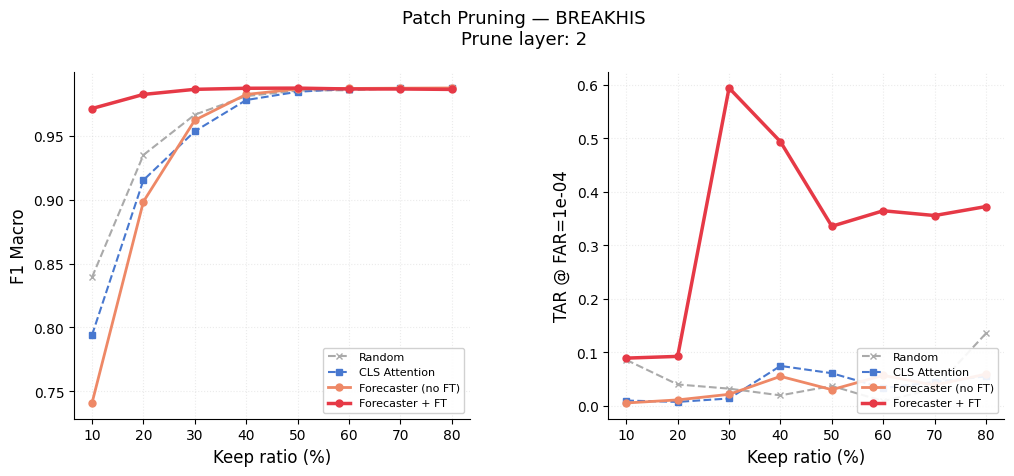

In [25]:


x_vals = [int(kr*100) for kr in CFG["keep_ratios"]]

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
fig.subplots_adjust(wspace=0.35)

for metric, ylabel, ax in [
    ("f1_macro",  "F1 Macro",             axes[0]),
    ("tar_at_far", f"TAR @ FAR={CFG['far_threshold']:.0e}", axes[1]),
]:
    for method_name, style in METHOD_STYLES.items():
        sub = df[df["method"] == method_name].sort_values("keep_pct")
        if sub.empty:
            continue
        ax.plot(sub["keep_pct"], sub[metric],
                color=style["color"], ls=style["ls"],
                marker=style["marker"], lw=style["lw"],
                label=method_name, markersize=5)

    ax.set_xlabel("Keep ratio (%)", fontsize=12)
    ax.set_ylabel(ylabel, fontsize=12)
    ax.set_xticks(x_vals)
    ax.tick_params(labelsize=10)
    ax.grid(alpha=0.25, linestyle=":")
    ax.spines[["top","right"]].set_visible(False)

axes[0].legend(fontsize=8, loc="lower right", framealpha=0.9,
               ncol=1, handlelength=2)
axes[1].legend(fontsize=8, loc="lower right", framealpha=0.9,
               ncol=1, handlelength=2)

fig.suptitle(f"Patch Pruning — {DATASET_NAME}\n"
             f"Prune layer: {CFG['prune_layer']}",
             fontsize=13, y=1.02)

plot_path = CFG["results_dir"] / "pruning_comparison.pdf"
fig.savefig(plot_path, dpi=300, bbox_inches="tight")
fig.savefig(str(plot_path).replace(".pdf",".png"), dpi=300, bbox_inches="tight")
print(f"Plot salvato in {plot_path}")
plt.show()

In [26]:
pivot_f1  = df.pivot(index="method", columns="keep_pct", values="f1_macro")
pivot_tar = df.pivot(index="method", columns="keep_pct", values="tar_at_far")

def to_latex_table(pivot, metric_name, dataset_name):
    cols = pivot.columns.tolist()
    header = " & ".join([f"{c}\\%" for c in cols])
    lines  = [
        f"\\begin{{table}}[h]",
        f"\\caption{{{metric_name} — {dataset_name}}}",
        f"\\begin{{tabular}}{{l{'c'*len(cols)}}}",
        f"\\toprule",
        f"Method & {header} \\\\",
        f"\\midrule",
    ]
    for method, row in pivot.iterrows():
        best_col = row.idxmax()
        vals = []
        for col in cols:
            v = row[col]
            if col == best_col:
                vals.append(f"\\textbf{{{v:.3f}}}")
            else:
                vals.append(f"{v:.3f}")
        lines.append(f"{method} & {' & '.join(vals)} \\\\")
    lines += ["\\bottomrule", "\\end{tabular}", "\\end{table}"]
    return "\n".join(lines)

latex_f1  = to_latex_table(pivot_f1,  "F1 Macro",  DATASET_NAME)
latex_tar = to_latex_table(pivot_tar, "TAR@FAR",   DATASET_NAME)

latex_path_f1  = CFG["results_dir"] / "table_f1.tex"
latex_path_tar = CFG["results_dir"] / "table_tar.tex"
latex_path_f1.write_text(latex_f1)
latex_path_tar.write_text(latex_tar)
print(f"Tabelle LaTeX salvate in {CFG['results_dir']}")
print("\n── F1 Macro ──")
print(latex_f1)

Tabelle LaTeX salvate in results/BREAKHIS

── F1 Macro ──
\begin{table}[h]
\caption{F1 Macro — BREAKHIS}
\begin{tabular}{lcccccccc}
\toprule
Method & 10\% & 20\% & 30\% & 40\% & 50\% & 60\% & 70\% & 80\% \\
\midrule
CLS Attention & 0.794 & 0.915 & 0.953 & 0.978 & 0.984 & 0.987 & 0.987 & \textbf{0.987} \\
Forecaster (no FT) & 0.741 & 0.898 & 0.962 & 0.982 & 0.987 & 0.987 & 0.987 & \textbf{0.987} \\
Forecaster + FT & 0.971 & 0.982 & 0.986 & 0.987 & \textbf{0.987} & 0.987 & 0.987 & 0.986 \\
Random & 0.839 & 0.935 & 0.966 & 0.981 & 0.985 & 0.986 & \textbf{0.987} & 0.987 \\
\bottomrule
\end{tabular}
\end{table}
